# agentv16_async_graph — Async LangGraph Execution

This version introduces async graph execution.

Graph:

```text
START → planner → async_fetch_metrics → async_fetch_logs → summarize → END
```

We will use:
- async nodes
- `await graph.ainvoke(...)`
- `async for chunk in graph.astream(...)`
- async LLM calls


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define state using NotRequired


In [3]:
from typing import NotRequired, TypedDict

class AgentState(TypedDict):
    input: str
    plan: NotRequired[str]
    metrics_result: NotRequired[str]
    logs_result: NotRequired[str]
    final_answer: NotRequired[str]


## 4. Define async planner node


In [4]:
import asyncio

async def planner_node(state: AgentState) -> AgentState:
    await asyncio.sleep(0.1)
    return {
        "plan": (
            "Plan: collect metrics, collect logs, then synthesize the likely cause "
            "and next action."
        )
    }


## 5. Define async I/O functions

These simulate slow external calls.

In production, these could be:
- AWS CloudWatch API calls
- HTTP requests
- database queries
- MCP tool calls


In [5]:
async def fetch_cloudwatch_metrics() -> str:
    await asyncio.sleep(1.0)
    return (
        "Metrics: CHECK-DOMAIN p95 response_time increased to 240 ms after R13; "
        "timeout volume increased for client_b."
    )

async def fetch_cloudwatch_logs() -> str:
    await asyncio.sleep(1.0)
    return (
        "Logs: repeated CONNECTION_TIMEOUT events for upstream registry endpoint "
        "during peak traffic windows."
    )


## 6. Define async graph nodes


In [6]:
async def async_fetch_metrics_node(state: AgentState) -> AgentState:
    result = await fetch_cloudwatch_metrics()
    return {"metrics_result": result}

async def async_fetch_logs_node(state: AgentState) -> AgentState:
    result = await fetch_cloudwatch_logs()
    return {"logs_result": result}


## 7. Define async LLM summary node


In [7]:
from langchain_openai import ChatOpenAI

async def summarize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
User request:
{state["input"]}

Plan:
{state["plan"]}

Metrics:
{state["metrics_result"]}

Logs:
{state["logs_result"]}

Write a concise incident analysis with likely cause and next action.
'''

    response = await llm.ainvoke(prompt)
    return {"final_answer": response.content}


## 8. Build async graph


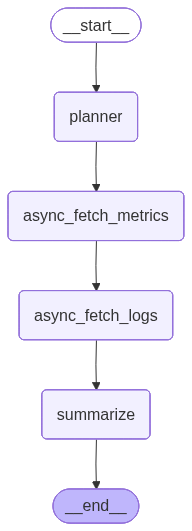

In [8]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("planner", planner_node)
    graph_builder.add_node("async_fetch_metrics", async_fetch_metrics_node)
    graph_builder.add_node("async_fetch_logs", async_fetch_logs_node)
    graph_builder.add_node("summarize", summarize_node)

    graph_builder.add_edge(START, "planner")
    graph_builder.add_edge("planner", "async_fetch_metrics")
    graph_builder.add_edge("async_fetch_metrics", "async_fetch_logs")
    graph_builder.add_edge("async_fetch_logs", "summarize")
    graph_builder.add_edge("summarize", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 9. Visualize Mermaid graph


In [9]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	async_fetch_metrics(async_fetch_metrics)
	async_fetch_logs(async_fetch_logs)
	summarize(summarize)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	async_fetch_logs --> summarize;
	async_fetch_metrics --> async_fetch_logs;
	planner --> async_fetch_metrics;
	summarize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 10. Visualize PNG graph


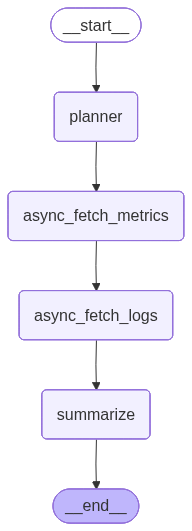

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 11. Run async graph with `ainvoke`

In Jupyter, you can use `await` directly.


In [11]:
result = await graph.ainvoke({
    "input": "Investigate EPP CHECK-DOMAIN latency after release R13."
})

print(result["final_answer"])


### Incident Analysis: EPP CHECK-DOMAIN Latency Post R13 Release

**Incident Overview:**
Following the release of R13, the CHECK-DOMAIN service has experienced a significant increase in latency, with the p95 response time rising to 240 ms. Additionally, there has been a notable increase in timeout volume for client_b, indicating potential service degradation.

**Metrics Analysis:**
- **Response Time:** The p95 response time for CHECK-DOMAIN increased to 240 ms, suggesting that a substantial portion of requests are experiencing delays.
- **Timeout Volume:** The increase in timeout volume for client_b indicates that requests are failing to complete within the expected timeframe, leading to a poor user experience.

**Logs Analysis:**
- **CONNECTION_TIMEOUT Events:** The logs show repeated CONNECTION_TIMEOUT events for the upstream registry endpoint, particularly during peak traffic windows. This suggests that the upstream service may be struggling to handle the load, leading to increased 

## 12. Stream async graph updates


In [ ]:
async for chunk in graph.astream(
    {"input": "Investigate EPP CHECK-DOMAIN latency after release R13."},
    stream_mode="updates",
):
    print("\n--- async update ---")
    print(chunk)


## 13. Concurrent async work inside one node

If two external calls are independent, use `asyncio.gather`.

This is different from graph-level parallel branches. It is concurrency inside a single node.


In [ ]:
async def combined_fetch_node(state: AgentState) -> AgentState:
    metrics, logs = await asyncio.gather(
        fetch_cloudwatch_metrics(),
        fetch_cloudwatch_logs(),
    )
    return {
        "metrics_result": metrics,
        "logs_result": logs,
    }

combined = await combined_fetch_node({"input": "test"})
combined


## 14. Async vs parallel graph branches

Async means non-blocking execution.

Parallel graph branches mean multiple graph paths can run independently.

You can combine both patterns in production.


## 15. LangSmith trace

Open project:

```text
langgraph-playground
```

Inspect async node execution and async LLM call traces.
